✅ Step 1: Install Required Libraries

In [1]:
pip install transformers datasets accelerate timm decord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 86.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu1

✅ Step 2: Load Pretrained ViViT Model + Feature Extractor

In [2]:
from transformers import VideoMAEFeatureExtractor, VideoMAEForVideoClassification

# Load feature extractor and pretrained model
feature_extractor = VideoMAEFeatureExtractor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

#  Prepares (resizes, normalizes) video frames for the model.
# This is the pretrained ViViT model, already trained on the Kinetics-400 dataset.

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/videomae/feature_extraction_videomae.py:30: FutureWarning: The class VideoMAEFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use VideoMAEImageProcessor instead.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

 Load the Dataset

What frame size the model expects (e.g., 224×224) <br>
How many frames (e.g., 16 frames from a video) <br>
What kind of normalization/scaling to apply

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

# Path to the zip file in Drive
zip_path = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/dataset/ddd.zip"

# Unzip it to /content/
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/Sexual_Harassment_Dataset")

# Set dataset path
dataset_path = "/content/Sexual_Harassment_Dataset"

In [6]:
import os

# List top-level files/folders
print(os.listdir("/content/Sexual_Harassment_Dataset"))

# If it's nested, explore further:
for root, dirs, files in os.walk("/content/Sexual_Harassment_Dataset"):
    print("Root:", root)
    print("Dirs:", dirs)
    print("Files:", files[:5])  # just print the first 5 files
    print("===")

['d']
Root: /content/Sexual_Harassment_Dataset
Dirs: ['d']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/d
Dirs: ['No_Harassment', 'Harassment']
Files: []
===
Root: /content/Sexual_Harassment_Dataset/d/No_Harassment
Dirs: []
Files: ['no_haras_79.mp4', 'no_haras_702.mp4', 'no_haras_2.mp4', 'no_haras_410.mp4', 'no_haras_586.mp4']
===
Root: /content/Sexual_Harassment_Dataset/d/Harassment
Dirs: []
Files: ['haras_140.mp4', 'haras_251.mp4', 'haras_277.mp4', 'haras_13.mp4', 'haras_70.mp4']
===


Step 3: Prepare Your Dataset List


In [7]:
import os
from decord import VideoReader, cpu

dataset_path = "/content/Sexual_Harassment_Dataset/d"

def count_unreadable_videos(root_dir):
    unreadable = []
    total = 0

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.lower().endswith(".mp4"):
                total += 1
                video_path = os.path.join(root, file)

                try:
                    vr = VideoReader(video_path, ctx=cpu(0))
                    if len(vr) == 0:
                        unreadable.append(video_path)
                except:
                    unreadable.append(video_path)

    print(f"📦 Total videos found: {total}")
    print(f"❌ Unreadable videos: {len(unreadable)}\n")

    if unreadable:
        print("List of unreadable videos:")
        for path in unreadable:
            print(path)

count_unreadable_videos(dataset_path)


📦 Total videos found: 791
❌ Unreadable videos: 0



In [8]:
import os
from decord import VideoReader, cpu
import numpy as np

def get_video_paths_labels(root_dir):
    video_paths = []
    labels = []
    label_map = {'No_Harassment': 0, 'Harassment': 1}
    unreadable_videos_count = 0

    for cls in label_map:
        cls_folder = os.path.join(root_dir, cls)
        for fname in os.listdir(cls_folder):
            if fname.endswith('.mp4'):
                video_path = os.path.join(cls_folder, fname)
                try:
                    # Attempt to read the video to check if it's accessible and readable
                    vr = VideoReader(video_path, ctx=cpu(0))
                    _ = len(vr) # Check if length can be obtained
                    video_paths.append(video_path)
                    labels.append(label_map[cls])
                except Exception as e:
                    print(f"Warning: Could not read video {video_path}. Skipping. Error: {e}")
                    unreadable_videos_count += 1

    print(f"\nFound {unreadable_videos_count} unreadable videos that were skipped.")
    return video_paths, labels, label_map

video_paths, labels, label_map = get_video_paths_labels("/content/Sexual_Harassment_Dataset/d")


Found 0 unreadable videos that were skipped.


Step 4: Split Dataset Into Train & Validation

In [9]:
from sklearn.model_selection import train_test_split

train_paths, val_paths, train_labels, val_labels = train_test_split(
    video_paths, labels, test_size=0.20, stratify=labels, random_state=42
)


In [10]:
import os

# Display the first training video path
print("First training video:", train_paths[0])
print("\nFirst 5 training videos:")
for i in range(min(5, len(val_paths))):
    print(train_paths[i])

# Display the first 5 validation video paths
print("\nFirst 5 validation videos:")
for i in range(min(5, len(val_paths))):
    print(val_paths[i])

First training video: /content/Sexual_Harassment_Dataset/d/Harassment/haras_108.mp4

First 5 training videos:
/content/Sexual_Harassment_Dataset/d/Harassment/haras_108.mp4
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_377.mp4
/content/Sexual_Harassment_Dataset/d/Harassment/haras_275.mp4
/content/Sexual_Harassment_Dataset/d/Harassment/haras_70.mp4
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_555.mp4

First 5 validation videos:
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_760.mp4
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_305.mp4
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_379.mp4
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_450.mp4
/content/Sexual_Harassment_Dataset/d/No_Harassment/no_haras_222.mp4


Step 5: Create Dataset Class

In [11]:
from torch.utils.data import Dataset
from decord import VideoReader, cpu
import numpy as np

class SignLanguageDataset(Dataset):
    def __init__(self, video_paths, labels, feature_extractor, num_frames=16):
        self.video_paths = video_paths
        self.labels = labels
        self.feature_extractor = feature_extractor
        self.num_frames = num_frames

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        vr = VideoReader(self.video_paths[idx], ctx=cpu(0))
        total_frames = len(vr)
        indices = np.linspace(0, total_frames-1, min(self.num_frames, total_frames)).astype(int)
        frames = vr.get_batch(indices).asnumpy()
        inputs = self.feature_extractor(list(frames), return_tensors="pt")
        return inputs["pixel_values"].squeeze(0), self.labels[idx]

Step 6: Create DataLoaders

In [12]:
from torch.utils.data import DataLoader

train_dataset = SignLanguageDataset(train_paths, train_labels, feature_extractor)
val_dataset = SignLanguageDataset(val_paths, val_labels, feature_extractor)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2)

In [13]:
for i, (pixel_values, labels) in enumerate(train_loader):
    print(f"Batch {i+1}")
    print("Pixel values shape:", pixel_values.shape)  # Should be (B, T, C, H, W) or (B, 3, 16, 224, 224) after permute
    print("Labels:", labels)
    if i == 1:  # print only first 2 batches
        break


Batch 1
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([1, 1])
Batch 2
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 0])


In [14]:
for i, (pixel_values, labels) in enumerate(val_loader):
    print(f"Validation Batch {i+1}")
    print("Pixel values shape:", pixel_values.shape)
    print("Labels:", labels)
    if i == 1:
        break

Validation Batch 1
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 0])
Validation Batch 2
Pixel values shape: torch.Size([2, 16, 3, 224, 224])
Labels: tensor([0, 0])


In [15]:
for label_idx in labels:
    for class_name, idx in label_map.items():
        if idx == label_idx.item():
            print(f"Label {label_idx.item()} corresponds to class: {class_name}")

Label 0 corresponds to class: No_Harassment
Label 0 corresponds to class: No_Harassment


In [16]:
# From (B, T, C, H, W) to (B, C, T, H, W)

for pixel_values, labels in train_loader:
    print("Before permute:", pixel_values.shape)
    pixel_values = pixel_values.permute(0, 2, 1, 3, 4)
    print("After permute:", pixel_values.shape)
    break

Before permute: torch.Size([2, 16, 3, 224, 224])
After permute: torch.Size([2, 3, 16, 224, 224])


In [17]:
print(pixel_values.shape)

torch.Size([2, 3, 16, 224, 224])


In [18]:
print(f"Number of training videos: {len(train_dataset)}")
print(f"Number of validation videos: {len(val_dataset)}")

Number of training videos: 632
Number of validation videos: 159


In [19]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")

Number of training batches: 316
Number of validation batches: 80


In [20]:
print(f"Number of classes: {len(label_map)}")

Number of classes: 2


In [21]:
print(f"Label map: {label_map}")

Label map: {'No_Harassment': 0, 'Harassment': 1}


Step 7: Adjust Model Output Layer

In [22]:
import torch.nn as nn

num_classes = len(label_map)
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.config.num_labels = num_classes

Step 8: Training Loop with Validation & Best Model Saving

In [24]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# =====================
# Device Setup
# =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"✅ Using device: {device}")

# =====================
# Loss, Optimizer, Scheduler
# =====================
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=5e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

# =====================
# Model Save Path
# =====================
best_val_loss = float('inf')
save_path = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/Model/vivit_best_model_E20.pth"

# =====================
# Metric Storage
# =====================
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# Reverse label map for report
idx_to_class = {v: k for k, v in label_map.items()}

# =====================
# Training Loop
# =====================
num_epochs = 20

for epoch in range(num_epochs):
    print(f"\n🎯 Epoch {epoch + 1}/{num_epochs}")

    # ----- Training -----
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for pixel_values, labels in train_loader:
        pixel_values, labels = pixel_values.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()

        # Track train metrics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_running_loss, correct, total = 0.0, 0, 0
    true_labels, pred_labels = [], []

    with torch.no_grad():
        for pixel_values, labels in val_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.logits, 1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(predicted.cpu().numpy())

    avg_val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * correct / total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    # ----- Print Epoch Metrics -----
    print(f"📉 Train Loss: {avg_train_loss:.4f} | 📈 Val Loss: {avg_val_loss:.4f} | "
          f"✅ Train Acc: {train_acc:.2f}% | ✅ Val Acc: {val_acc:.2f}%")

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Show current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f"📉 Current Learning Rate: {current_lr:.6f}")

    # Save Best Model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), save_path)
        print(f"💾 Best model saved with val loss {best_val_loss:.4f} to {save_path}")

    # Classification Report
    print("\n🧾 Classification Report:")
    print(classification_report(
        [idx_to_class[i] for i in true_labels],
        [idx_to_class[i] for i in pred_labels],
        digits=3
    ))

✅ Using device: cuda

🎯 Epoch 1/20
📉 Train Loss: 0.4291 | 📈 Val Loss: 0.2997 | ✅ Train Acc: 81.80% | ✅ Val Acc: 86.16%
📉 Current Learning Rate: 0.000050
💾 Best model saved with val loss 0.2997 to /content/drive/MyDrive/ModelTrain/Sexual_Harassment/Model/vivit_best_model_E20.pth

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.797     0.825     0.810        57
No_Harassment      0.900     0.882     0.891       102

     accuracy                          0.862       159
    macro avg      0.848     0.853     0.851       159
 weighted avg      0.863     0.862     0.862       159


🎯 Epoch 2/20
📉 Train Loss: 0.1034 | 📈 Val Loss: 0.6800 | ✅ Train Acc: 96.04% | ✅ Val Acc: 80.50%
📉 Current Learning Rate: 0.000050

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      1.000     0.456     0.627        57
No_Harassment      0.767     1.000     0.868       102

     accuracy                        

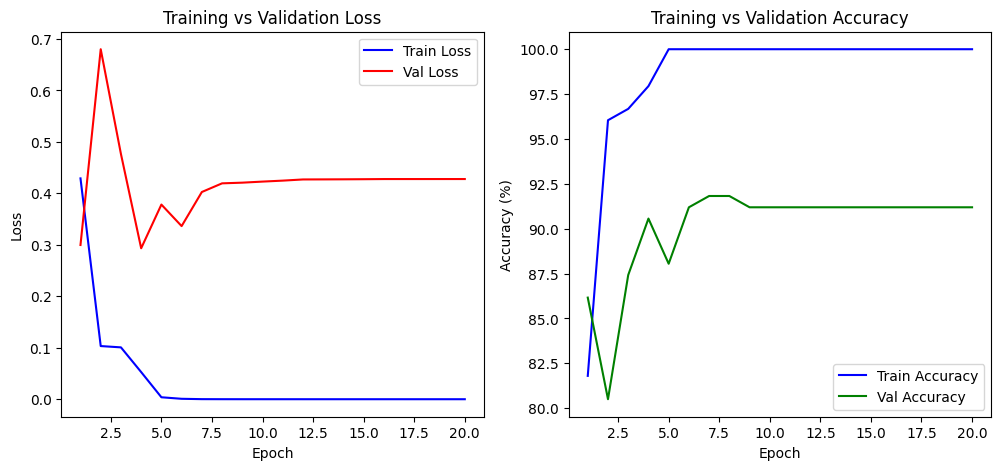

In [25]:
# =====================
# Plot Loss & Accuracy Curves
# =====================
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# ----- Loss Curve -----
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# ----- Accuracy Curve -----
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'g-', label='Val Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

Load the best Model

In [26]:
best_model = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/Model/vivit_best_model_E20.pth"

In [27]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation function
def evaluate(model, dataloader, label_map, device):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    val_loss = 0
    true_labels = []
    pred_labels = []

    with torch.no_grad():
        for pixel_values, labels in dataloader:
            pixel_values = pixel_values.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=pixel_values)
            loss = criterion(outputs.logits, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            true_labels.extend(labels.cpu().numpy())
            pred_labels.extend(preds.cpu().numpy())

    avg_loss = val_loss / len(dataloader)
    accuracy = accuracy_score(true_labels, pred_labels)

    # Convert index to class names
    idx_to_class = {v: k for k, v in label_map.items()}
    true_class_names = [idx_to_class[i] for i in true_labels]
    pred_class_names = [idx_to_class[i] for i in pred_labels]

    # Classification report
    report = classification_report(true_class_names, pred_class_names, digits=3)

    return avg_loss, accuracy, report, true_class_names, pred_class_names


Validation Accuracy: 90.57%
💾 Validation Loss: 0.2933

🧾 Classification Report:
               precision    recall  f1-score   support

   Harassment      0.977     0.754     0.851        57
No_Harassment      0.878     0.990     0.931       102

     accuracy                          0.906       159
    macro avg      0.928     0.872     0.891       159
 weighted avg      0.914     0.906     0.902       159



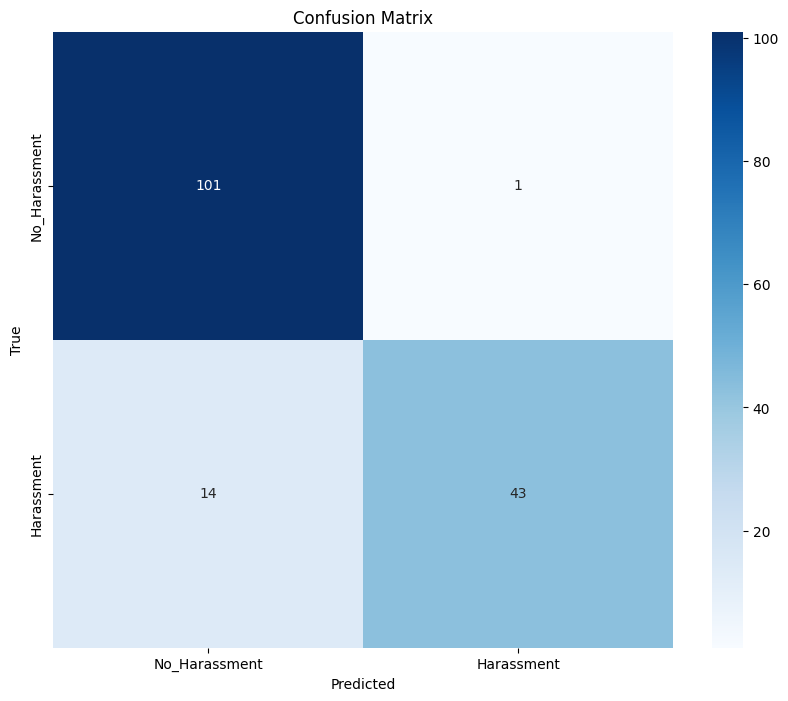

In [28]:
# Load best model
model.load_state_dict(torch.load(best_model))
model.to(device)
model.eval()

# Run evaluation
avg_test_loss, test_acc, report, true_class_names, pred_class_names = evaluate(model, val_loader, label_map, device)

# Print results
print(f"Validation Accuracy: {test_acc * 100:.2f}%")
print(f"💾 Validation Loss: {avg_test_loss:.4f}")
print("\n🧾 Classification Report:")
print(report)

# Plot Confusion Matrix
idx_to_class = {v: k for k, v in label_map.items()}
class_names = list(idx_to_class.values())

cm = confusion_matrix(true_class_names, pred_class_names, labels=class_names)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [29]:
# Make sure num_classes is still set correctly
model.classifier = nn.Linear(model.classifier.in_features, num_classes)
model.load_state_dict(torch.load(best_model))
model.eval()
model.to(device)

VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0-11): 12 x VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
    

In [30]:
def predict_video(video_path, model, feature_extractor, label_map, num_frames=16):
    # Load video frames
    vr = VideoReader(video_path, ctx=cpu(0))
    total_frames = len(vr)
    indices = np.linspace(0, total_frames - 1, min(num_frames, total_frames)).astype(int)
    frames = vr.get_batch(indices).asnumpy()

    # Preprocess
    inputs = feature_extractor(list(frames), return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    # Inference
    with torch.no_grad():
        outputs = model(pixel_values)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred_class_idx = torch.argmax(probs, dim=1).item()

    # Map index to class name
    class_name = [k for k, v in label_map.items() if v == pred_class_idx][0]
    confidence = probs[0][pred_class_idx].item()
    return class_name, confidence

In [32]:
video_path = "/content/Sexual_Harassment_Dataset/d/Harassment/haras_1.mp4"  # <-- change this to your actual file
pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)
print(f"Predicted: {pred_class} ({confidence*100:.1f}%)")

Predicted: Harassment (99.9%)


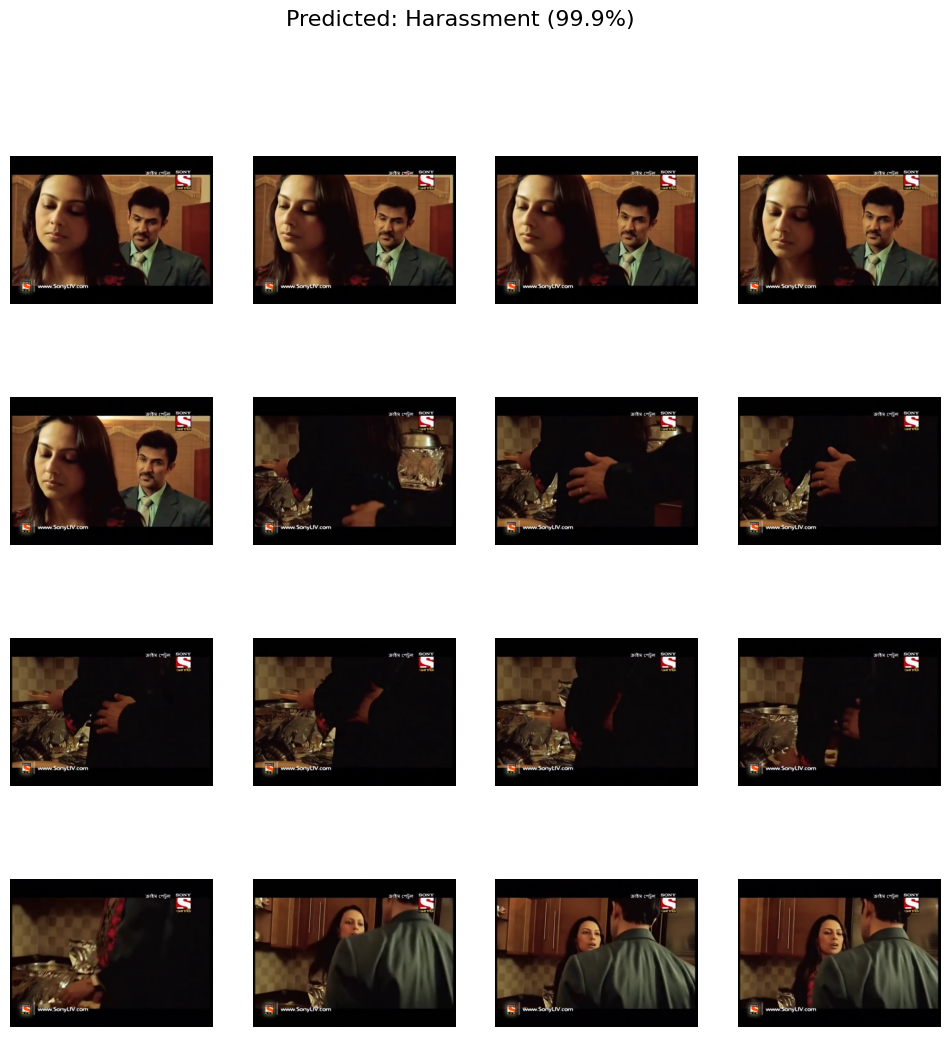

In [33]:
vr = VideoReader(video_path, ctx=cpu(0))
frames = vr.get_batch(np.linspace(0, len(vr)-1, 16).astype(int)).asnumpy()

import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(frames[i])
    ax.axis('off')
plt.suptitle(f"Predicted: {pred_class} ({confidence*100:.1f}%)", fontsize=16)
plt.show()

Check Every Video

In [34]:
import os
from decord import VideoReader, cpu
import numpy as np
import torch.nn.functional as F

def predict_video(video_path, model, feature_extractor, label_map, num_frames=16):
    vr = VideoReader(video_path, ctx=cpu(0))
    total_frames = len(vr)
    indices = np.linspace(0, total_frames - 1, min(num_frames, total_frames)).astype(int)
    frames = vr.get_batch(indices).asnumpy()
    inputs = feature_extractor(list(frames), return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        outputs = model(pixel_values)
        probs = F.softmax(outputs.logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_idx].item()

    pred_class = [k for k, v in label_map.items() if v == pred_idx][0]
    return pred_class, confidence

In [35]:
import os
from collections import defaultdict

# ANSI color codes
RED = "\033[91m"
RESET = "\033[0m"

dataset_root = "/content/Sexual_Harassment_Dataset/d"

# Track incorrect/correct counts per class
incorrect_counts = defaultdict(int)
total_counts = defaultdict(int)

# Track global totals
total_videos = 0
total_correct = 0

for class_folder in os.listdir(dataset_root):
    folder_path = os.path.join(dataset_root, class_folder)
    if not os.path.isdir(folder_path):
        continue

    print(f"\n📂 Class folder: {class_folder}")

    for video_file in os.listdir(folder_path):
        if not video_file.endswith(".mp4"):
            continue

        video_path = os.path.join(folder_path, video_file)

        try:
            pred_class, confidence = predict_video(video_path, model, feature_extractor, label_map)
            total_counts[class_folder] += 1
            total_videos += 1

            if pred_class != class_folder:
                incorrect_counts[class_folder] += 1
                print(f"{RED}📹 {video_file} → Predicted: {pred_class} ({confidence*100:.1f}%) [Expected: {class_folder}]{RESET}")
            else:
                total_correct += 1
                print(f"📹 {video_file} → Predicted: {pred_class} ({confidence*100:.1f}%)")

        except Exception as e:
            print(f"⚠️ Failed on {video_file}: {e}")

# 🔢 Summary of incorrect predictions
print("\n📊 Class-wise Prediction Summary:")
for class_name in sorted(total_counts):
    total = total_counts[class_name]
    incorrect = incorrect_counts[class_name]
    correct = total - incorrect
    print(f"🔹 {class_name}: {incorrect} incorrect out of {total} → Accuracy: {correct / total * 100:.1f}%")

# 🎯 Total accuracy
if total_videos > 0:
    total_accuracy = total_correct / total_videos * 100
    print(f"\n🎯 Total Accuracy: {total_correct} correct out of {total_videos} → {total_accuracy:.2f}%")
else:
    print("\n⚠️ No videos found to evaluate.")


📂 Class folder: No_Harassment
📹 no_haras_79.mp4 → Predicted: No_Harassment (100.0%)
📹 no_haras_702.mp4 → Predicted: No_Harassment (85.1%)
📹 no_haras_2.mp4 → Predicted: No_Harassment (100.0%)
📹 no_haras_410.mp4 → Predicted: No_Harassment (99.9%)
📹 no_haras_586.mp4 → Predicted: No_Harassment (100.0%)
📹 no_haras_550.mp4 → Predicted: No_Harassment (100.0%)
📹 no_haras_176.mp4 → Predicted: No_Harassment (99.8%)
📹 no_haras_83.mp4 → Predicted: No_Harassment (99.9%)
📹 no_haras_582.mp4 → Predicted: No_Harassment (99.2%)
📹 no_haras_510.mp4 → Predicted: No_Harassment (100.0%)
📹 no_haras_478.mp4 → Predicted: No_Harassment (99.3%)
📹 no_haras_507.mp4 → Predicted: No_Harassment (99.9%)
📹 no_haras_615.mp4 → Predicted: No_Harassment (99.9%)
📹 no_haras_222.mp4 → Predicted: No_Harassment (91.8%)
📹 no_haras_357.mp4 → Predicted: No_Harassment (99.9%)
📹 no_haras_511.mp4 → Predicted: No_Harassment (100.0%)
📹 no_haras_584.mp4 → Predicted: No_Harassment (99.9%)
📹 no_haras_301.mp4 → Predicted: No_Harassment (10

In [ ]:
import torch
import cv2
from transformers import VideoMAEConfig, VideoMAEForVideoClassification, VideoMAEImageProcessor
import sys

# ========== Settings ==========
VIDEO_PATH = "/content/test.mp4"  # Or 0 for webcam
# Assuming the model file is in the same directory as the extracted dataset
best_model = "/content/drive/MyDrive/ModelTrain/Sexual_Harassment/Model/vivit_best_model_E20.pth"
LABELS = ["No_Harassment", "Harassment"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_FRAMES = 16
IMG_SIZE = 224

# ========== Load Model ==========
print("Loading model...")
state_dict = torch.load(best_model, map_location=DEVICE)
config = VideoMAEConfig()
config.num_labels = len(LABELS)
model = VideoMAEForVideoClassification(config)
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()

processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")

# ========== Frame Preprocessing ==========
def preprocess_frames(frames):
    rgb = [cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frames]
    inputs = processor(images=rgb, return_tensors="pt")
    return inputs.to(DEVICE)

# ========== Display Handling ==========
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab.patches import cv2_imshow

def show_frame(frame):
    if IN_COLAB:
        cv2_imshow(frame)
    else:
        cv2.imshow("Labeled Video", frame)

# ========== Step 1: Classify and Label Video ==========
print("Processing video...")
cap = cv2.VideoCapture(VIDEO_PATH)
frame_buffer = []
processed_frames = []
font = cv2.FONT_HERSHEY_SIMPLEX

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_buffer.append(frame)

    if len(frame_buffer) == NUM_FRAMES:
        inputs = preprocess_frames(frame_buffer)
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            pred = logits.argmax(-1).item()
            confidence = torch.softmax(logits, dim=1)[0, pred].item()
            label = f"{LABELS[pred]} ({confidence:.2f})"
            color = (0, 0, 255) if LABELS[pred] == "Harassment" else (0, 255, 0)

        for f in frame_buffer:
            cv2.putText(f, label, (50, 50), font, 1.2, color, 3)
            processed_frames.append(f)

        frame_buffer = []

# Release original video
cap.release()
print(f"Total labeled frames: {len(processed_frames)}")

# ========== Step 2: Playback Labeled Video ==========
print("Playing labeled video...")
for f in processed_frames:
    show_frame(f)
    if not IN_COLAB:
        if cv2.waitKey(30) & 0xFF == ord('q'):
            break

# Wait and close
if not IN_COLAB:
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [41]:
# Optional: Save output video
print("Saving labeled video to 'labeled_output.mp4'...")
h, w = processed_frames[0].shape[:2]
out = cv2.VideoWriter("labeled_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 30, (w, h))

for f in processed_frames:
    out.write(f)
out.release()
print("Saved successfully.")

Saving labeled video to 'labeled_output.mp4'...
Saved successfully.
